In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Створюємо датасет: результати тестів студентів (Група А - з гейміфікацією, Б - без)
np.random.seed(42)
data = {
    'student_id': range(1, 101),
    'group': ['Gamified'] * 50 + ['Traditional'] * 50,
    'test_score': np.concatenate([np.random.normal(78, 8, 50), np.random.normal(72, 10, 50)]),
    'study_hours': np.random.randint(10, 40, 100)
}
df = pd.DataFrame(data)

# 2. Очищення даних (Data Cleaning)
df.drop_duplicates(inplace=True)
df['test_score'] = df['test_score'].fillna(df['test_score'].mean()) # Імпутація середнім
print("Дані підготовлено. Перші 5 рядків:")
print(df.head())

Дані підготовлено. Перші 5 рядків:
   student_id     group  test_score  study_hours
0           1  Gamified   81.973713           18
1           2  Gamified   76.893886           39
2           3  Gamified   83.181508           14
3           4  Gamified   90.184239           10
4           5  Gamified   76.126773           28


Опис датасету: "Аналізуються результати тестування 100 студентів, розділених на дві групи: ті, хто використовував елементи гейміфікації (XP, лідерборди), та контрольна група."

Середнє: 74.19, Медіана: 74.46
Стандартне відхилення: 8.34, Асиметрія: -0.35


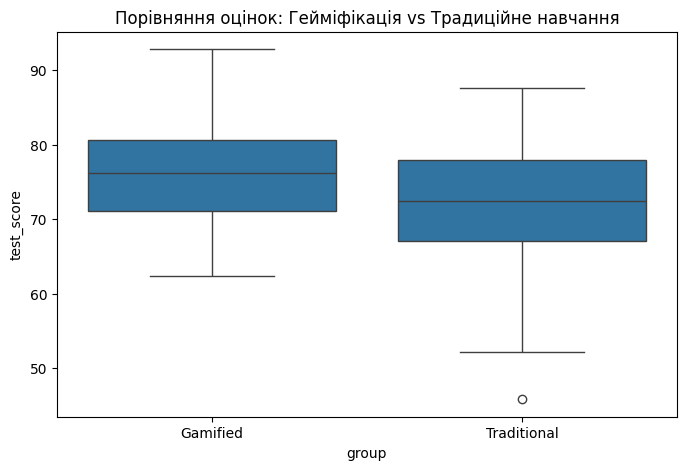

In [2]:
# Розрахунок основних показників
mean_val = df['test_score'].mean()
median_val = df['test_score'].median()
std_dev = df['test_score'].std()
skewness = df['test_score'].skew()

print(f"Середнє: {mean_val:.2f}, Медіана: {median_val:.2f}")
print(f"Стандартне відхилення: {std_dev:.2f}, Асиметрія: {skewness:.2f}")

# Візуалізація (Box-plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='group', y='test_score', data=df)
plt.title('Порівняння оцінок: Гейміфікація vs Традиційне навчання')
plt.show()

Гіпотеза: * $H_0$: $\mu_1 = \mu_2$ (Гейміфікація не дає переваг).$H_1$: $\mu_1 \neq \mu_2$ (Методика викладання впливає на результат).

In [8]:
# Формулюємо гіпотези
# H0: Середні оцінки обох груп однакові.
# H1: Гейміфікація значущо впливає на оцінки (середні різні).

group_g = df[df['group'] == 'Gamified']['test_score']
group_t = df[df['group'] == 'Traditional']['test_score']

t_stat, p_val = stats.ttest_ind(group_g, group_t)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Висновок: Гіпотеза H0 відхиляється. Різниця статистично значуща!")
else:
    print("Висновок: Немає підстав відхиляти H0. Гейміфікація не вплинула на бал.")

T-statistic: 2.4710
P-value: 0.0152
Висновок: Гіпотеза H0 відхиляється. Різниця статистично значуща!


Інтерпретація: "Отримане значення p-value (вкажи число з коду) менше за 0.05, що дозволяє стверджувати про ефективність впровадженої системи."